# Workbench Setup

In [1]:
import sys, os, collections
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt; plt.rcdefaults()
from matplotlib.pyplot import figure
from collections import Counter

In [2]:
# First we load the TF program
from tf.fabric import Fabric
from tf.app import use

In [3]:
pd.set_option('display.max_rows', None)

In [4]:
%%time
# Now we load a few databases
#BHSaLatest = use('etcbc/bhsa:latest')
#BHSaC = use('etcbc/bhsa', version='c', mod='CenterBLC/BHSaddons/tf')
#BHSa2017 = use('etcbc/bhsa', version='2017', mod='CenterBLC/BHSaddons/tf')

BHS = use('etcbc/bhsa', version="2021", mod='CenterBLC/BHSaddons/tf', hoist=globals())
bhsF, bhsL, bhsT, bhsS = BHS.api.F, BHS.api.L, BHS.api.T, BHS.api.S

LXX = use("CenterBLC/LXX", version="1935", hoist=globals())
lxxF, lxxL, lxxT, lxxS = LXX.api.F, LXX.api.L, LXX.api.T, LXX.api.S

DSS = use('etcbc/dss', hoist=globals())
dssF, dssL, dssT, dssS = DSS.api.F, DSS.api.L, DSS.api.T, DSS.api.S

GNT = use ("CenterBLC/N1904", version="1.0.0", mod="CenterBLC/N1904/BOLcomplement/tf/", hoist=globals())
gntF, gntL, gntT, gntS = GNT.api.F, GNT.api.L, GNT.api.T, GNT.api.S

**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,39,10938.21,100
chapter,929,459.19,100
lex,9230,46.22,100
verse,23213,18.38,100
half_verse,45179,9.44,100
sentence,63717,6.70,100
sentence_atom,64514,6.61,100
clause,88131,4.84,100
clause_atom,90704,4.70,100
phrase,253203,1.68,100


**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,57,10941.98,100
chapter,1192,523.23,100
verse,30371,20.54,100
subverse,30419,20.50,100
word,623693,1.00,100


**Locating corpus resources ...**

...

**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,27,5102.93,100
chapter,260,529.92,100
verse,7944,17.34,100
sentence,8011,17.20,100
group,8945,7.01,46
clause,42506,8.36,258
wg,106868,6.88,533
phrase,69007,1.90,95
subphrase,116178,1.60,135
word,137779,1.00,100


Display is setup for viewtype [syntax-view](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/syntax-view.md#start)

See [here](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/viewtypes.md#start) for more information on viewtypes

CPU times: user 7.19 s, sys: 1.38 s, total: 8.57 s
Wall time: 9.3 s


# How to create TextGrammarBHS Prints of BHS texts?

## Defining the aim
We want to be able to display the Hebrew text of a given chapter in the following way:

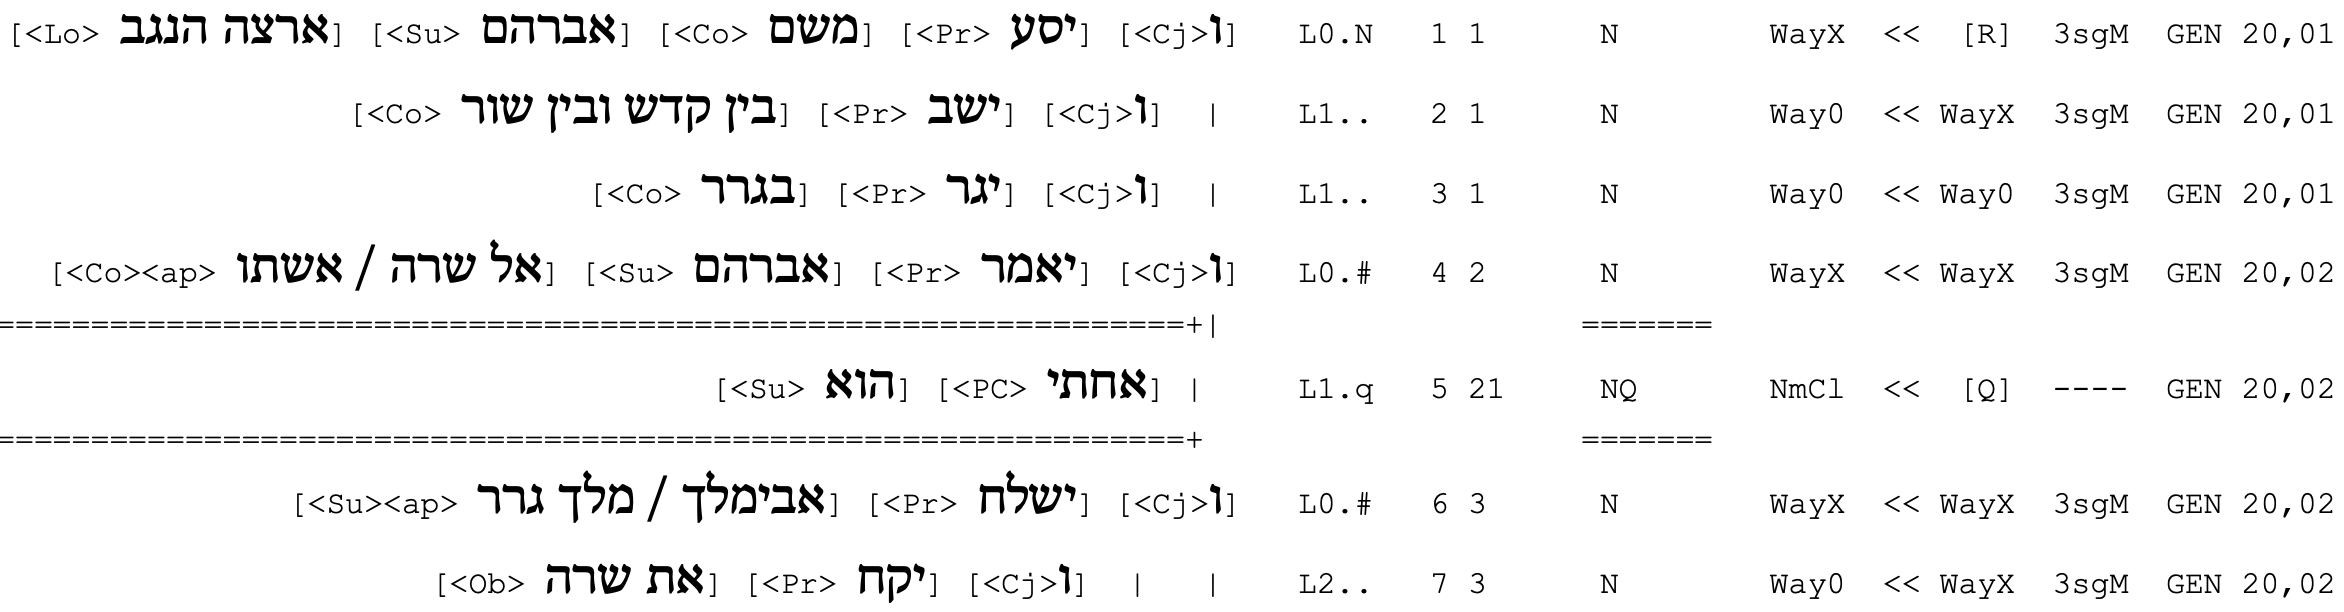

The procedure will look like this:
1. Identify the data a TF query will have to look for in order to retrieve the information needed for the TextGrammatical structure output.
2. Run the TF query an export the data.
3. Import the data as a DF.
4. Engage AI to see what typ of phython code needs to be ran in order to display the information in a way that resembles the desired aim.
5. Run and improve the phython code.
6. Export the result as odt/txt/docx/pdf file.

## Building TextGrammarBHS relevant TF query

### Query no1

In [5]:
bhsF.book.freqList(nodeTypes={"book"})

(('Amos', 1),
 ('Canticum', 1),
 ('Chronica_I', 1),
 ('Chronica_II', 1),
 ('Daniel', 1),
 ('Deuteronomium', 1),
 ('Ecclesiastes', 1),
 ('Esra', 1),
 ('Esther', 1),
 ('Exodus', 1),
 ('Ezechiel', 1),
 ('Genesis', 1),
 ('Habakuk', 1),
 ('Haggai', 1),
 ('Hosea', 1),
 ('Iob', 1),
 ('Jeremia', 1),
 ('Jesaia', 1),
 ('Joel', 1),
 ('Jona', 1),
 ('Josua', 1),
 ('Judices', 1),
 ('Leviticus', 1),
 ('Maleachi', 1),
 ('Micha', 1),
 ('Nahum', 1),
 ('Nehemia', 1),
 ('Numeri', 1),
 ('Obadia', 1),
 ('Proverbia', 1),
 ('Psalmi', 1),
 ('Reges_I', 1),
 ('Reges_II', 1),
 ('Ruth', 1),
 ('Sacharia', 1),
 ('Samuel_I', 1),
 ('Samuel_II', 1),
 ('Threni', 1),
 ('Zephania', 1))

In [36]:
TextGrammarBHS='''
verse book=Genesis chapter=20 verse=1|2|3|4|5|6|7
  clause typ txt* number* rela*
   clause_atom tab* typ* pargr* number* code*
     phrase function* number*
       phrase_atom rela* number*
'''
TextGrammarBHS = BHS.search(TextGrammarBHS)
BHS.table(TextGrammarBHS, start=1, end=1, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls','tab'}, condensed=False)

  0.50s 114 results


n,p,verse,clause,clause_atom,phrase,phrase_atom
1,Genesis 20:1,,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔גֶב,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔גֶב,וַ,וַ


### Query no2

In [57]:
TextGrammarBHS='''
verse book=Jeremia chapter=2 verse=10|11|12|13|14
  clause typ txt* number* rela*
   clause_atom tab* typ* pargr* number* code*
     phrase function* number*
       phrase_atom rela* number*
'''
TextGrammarBHS = BHS.search(TextGrammarBHS)
BHS.table(TextGrammarBHS, start=1, end=1, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls','tab'}, condensed=False)

  0.38s 61 results


n,p,verse,clause,clause_atom,phrase,phrase_atom
1,Jeremiah 2:10,,כִּ֣י עִבְר֞וּ אִיֵּ֤י כִתִּיִּים֙,כִּ֣י עִבְר֞וּ אִיֵּ֤י כִתִּיִּים֙,כִּ֣י,כִּ֣י


### Query no3

In [60]:
TextGrammarBHS='''
verse book=Genesis chapter=20 verse*
  clause typ txt* number* rela*
   clause_atom tab* typ* pargr* number* code*
     phrase function* number*
       phrase_atom rela* number*
'''
TextGrammarBHS = BHS.search(TextGrammarBHS)
BHS.table(TextGrammarBHS, start=1, end=1, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls','tab'}, condensed=False)

  0.56s 266 results


n,p,verse,clause,clause_atom,phrase,phrase_atom
1,Genesis 20:1,,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔גֶב,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔גֶב,וַ,וַ


### Query no4

In [27]:
TextGrammarBHS='''
verse book=Reges_I chapter=18 verse*
  clause typ txt* number* rela*
   clause_atom tab* typ* pargr* number* code*
     phrase function* number*
       phrase_atom rela* number*
'''
TextGrammarBHS = BHS.search(TextGrammarBHS)
BHS.table(TextGrammarBHS, start=1, end=1, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls','tab'}, condensed=False)

  0.43s 727 results


n,p,verse,clause,clause_atom,phrase,phrase_atom
1,1_Kings 18:1,,וַיְהִי֙ יָמִ֣ים רַבִּ֔ים,וַיְהִי֙ יָמִ֣ים רַבִּ֔ים,וַ,וַ


### Query Export

In [61]:
BHS.export(TextGrammarBHS, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export', toFile='TextGrammarBHS.tsv')

### DF loading of Query

In [62]:
TextGrammarBHS=pd.read_csv('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/TextGrammarBHS.tsv', delimiter='\t', encoding='utf-16')
pd.set_option('display.max_columns', 50)
TextGrammarBHS.head(5)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,number2,rela2,txt2,typ2,NODE3,TYPE3,TEXT3,code3,number3,pargr3,tab3,typ3,NODE4,TYPE4,TEXT4,function4,number4,NODE5,TYPE5,TEXT5,number5,rela5
0,1,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Genesis,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656884,phrase,וַ,Conj,1,910343,phrase_atom,וַ,5568,NaN
1,2,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Genesis,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656885,phrase,יִּסַּ֨ע,Pred,2,910344,phrase_atom,יִּסַּ֨ע,5569,NaN
2,3,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Genesis,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656886,phrase,מִשָּׁ֤ם,Cmpl,3,910345,phrase_atom,מִשָּׁ֤ם,5570,NaN
3,4,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Genesis,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656887,phrase,אַבְרָהָם֙,Subj,4,910346,phrase_atom,אַבְרָהָם֙,5571,NaN
4,5,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Genesis,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656888,phrase,אַ֣רְצָה הַנֶּ֔גֶב,Loca,5,910347,phrase_atom,אַ֣רְצָה הַנֶּ֔גֶב,5572,NaN


## Creating Abbreviations

In [63]:
#bhsF.book.freqList(nodeTypes={"book"})

In [64]:
#book_names = bhsF.book.freqList(nodeTypes={"book"})

## Convert to DataFrame directly
#book_names = pd.DataFrame(list(book_names), columns=["Book", "Frequency"])

## Optional: sort alphabetically or by frequency
#book_names = book_names.sort_values(by="Book").reset_index(drop=True)

## Show result
#print(book_names.head())


In [65]:
#book_names.to_csv("/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/df_freq.tsv", sep="\t", index=False)

In [66]:
# Mapping of BHS book names to SBL abbreviations
bhs_to_sbl = {
    'Genesis': 'Gen',
    'Exodus': 'Exod',
    'Leviticus': 'Lev',
    'Numeri': 'Num',
    'Deuteronomium': 'Deut',
    'Josua': 'Josh',
    'Judices': 'Judg',
    'Ruth': 'Ruth',
    'Samuel_I': '1_Sam',
    'Samuel_II': '2_Sam',
    'Reges_I': '1_Kgs',
    'Reges_II': '2_Kgs',
    'Chronica_I': '1_Chr',
    'Chronica_II': '2_Chr',
    'Esra': 'Ezra',
    'Nehemia': 'Neh',
    'Esther': 'Esth',
    'Iob': 'Job',
    'Psalmi': 'Ps',
    'Proverbia': 'Prov',
    'Ecclesiastes': 'Eccl',
    'Canticum': 'Song',
    'Jesaia': 'Isa',
    'Jeremia': 'Jer',
    'Threni': 'Lam',
    'Ezechiel': 'Ezek',
    'Daniel': 'Dan',
    'Hosea': 'Hos',
    'Joel': 'Joel',
    'Amos': 'Amos',
    'Obadia': 'Obad',
    'Jona': 'Jonah',
    'Micha': 'Mic',
    'Nahum': 'Nah',
    'Habakuk': 'Hab',
    'Zephania': 'Zeph',
    'Haggai': 'Hag',
    'Sacharia': 'Zech',
    'Maleachi': 'Mal'
}

In [67]:
TextGrammarBHS['book1_BHS'] = TextGrammarBHS['book1']
TextGrammarBHS['book1'] = TextGrammarBHS['book1'].map(bhs_to_sbl).fillna(TextGrammarBHS['book1'])
TextGrammarBHS.sort_values(by="NODE3", ascending=True, inplace=True) # needs to be done otherwise the clause_atom order is off in the CTT file.
TextGrammarBHS.head(5)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,number2,rela2,txt2,typ2,NODE3,TYPE3,TEXT3,code3,number3,pargr3,tab3,typ3,NODE4,TYPE4,TEXT4,function4,number4,NODE5,TYPE5,TEXT5,number5,rela5,book1_BHS
0,1,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Gen,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656884,phrase,וַ,Conj,1,910343,phrase_atom,וַ,5568,NaN,Genesis
1,2,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Gen,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656885,phrase,יִּסַּ֨ע,Pred,2,910344,phrase_atom,יִּסַּ֨ע,5569,NaN,Genesis
2,3,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Gen,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656886,phrase,מִשָּׁ֤ם,Cmpl,3,910345,phrase_atom,מִשָּׁ֤ם,5570,NaN,Genesis
3,4,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Gen,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656887,phrase,אַבְרָהָם֙,Subj,4,910346,phrase_atom,אַבְרָהָם֙,5571,NaN,Genesis
4,5,Genesis,20,1,1414885,verse,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,Gen,20,1,429286,clause,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,1,NaN,N,WayX,517495,clause_atom,וַיִּסַּ֨ע מִשָּׁ֤ם אַבְרָהָם֙ אַ֣רְצָה הַנֶּ֔...,0,1806,1,0,WayX,656888,phrase,אַ֣רְצָה הַנֶּ֔גֶב,Loca,5,910347,phrase_atom,אַ֣רְצָה הַנֶּ֔גֶב,5572,NaN,Genesis


## Converting `df` into an `RTF` file

### SIMPLE FORMAT **`WithOut`** DirectSpeech separator

In [72]:
## OG solution: Only simple list of clause atoms in sequence
import pandas as pd
from collections import defaultdict

df = TextGrammarBHS

def create_rtf_from_grammar(df):
    """
    Convert grammar TSV data to RTF format matching the CTT style.
    """
    
    def unicode_to_rtf(text):
        """Convert Unicode text to RTF Unicode escape sequences with Times New Roman font."""
        result = [r"\f1 "]  # Switch to Times New Roman for Hebrew
        for char in text:
            code = ord(char)
            if code > 127:
                result.append(f"\\u{code}?")
            else:
                result.append(char)
        result.append(r"\f0 ")  # Switch back to Courier New
        return ''.join(result)
    
    # RTF header
    rtf_content = [
        r"{\rtf1\ansi\ansicpg1252\deff0",
        r"{\fonttbl{\f0\fmodern Courier New;}{\f1\froman Times New Roman;}}",
        r"{\*\generator Python RTF Generator;}",
        r"\paperw28800\paperh86400",
        r"\margl720\margr720\margt720\margb720",
        r"\f0\fs20\uc1"
    ]

    # Group by clause type first to maintain proper sequence
    clauseatoms = df.groupby(['TYPE3'])
    
    for (clause_type), type_data in clauseatoms:
        # Now group by individual clause_atoms within this type
        clause_atoms = type_data.groupby('NODE3', sort=False)
        clauseatom_list = list(clause_atoms)

        # Stack to remember tab_level for each opened D-level
        d_stack = []

        # Stack to remember tab_level for each opened Q-level
        q_stack = []

        # Stack to remember tab_level for each opened N-level
        n_stack = []

        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            clause_data = clause_data.sort_values('NODE5')
            first_row = clause_data.iloc[0]

            clause_type = first_row['typ3']
            clause_rela = first_row['rela2']
            clause_atom_code = first_row['code3']
            text_type = first_row['txt2']
            tab_level = int(first_row['tab3'])
            clause_num = first_row['NODE3']
            paragraph = first_row['pargr3']
            book = first_row['book1']
            chapter = first_row['chapter1']
            verse = first_row['verse1']
            dot = "."



            # --- Build phraseatom sequence ---
            phraseatoms = []
            for _, row in clause_data.iterrows():
                function = row['function4']
                subphrase_rela = row['rela5']
                text = row['TEXT5']
                
                clean_text = text.strip() # Necessary since some phrase start with an empty space before the first consonant

                phraseatoms.append(
                    f"[<{subphrase_rela}> {unicode_to_rtf(clean_text)} <{function}>]" 
                    if subphrase_rela in ['Appo', 'Spec', 'Para', 'Link'] 
                    else f"[<{function}> {unicode_to_rtf(clean_text)}]"
                )

            phraseatoms.reverse()
            #spacing = "  |" * tab_level
            # Build the line parts with conditional clause_rela
            clause_rela_str = f"{clause_rela:<4}" if pd.notna(clause_rela) else "    "  # 4 spaces to maintain alignment            
            line_parts = [""] + phraseatoms + [f"  {clause_type:<6}{clause_rela_str} {clause_num:<7}{book:>5}{chapter:3d}:{verse:3d}"]

            rtf_content.append("\\par\\qr ")
            rtf_content.append(''.join(line_parts))



    # RTF footer
    rtf_content.append("}")
    return '\n'.join(rtf_content)



def save_grammar_to_rtf(df, output_file):
    """
    Save the grammar dataframe to an RTF file.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame loaded from TextGrammarBHS.tsv
    output_file : str
        Path to output RTF file
    """
    rtf_content = create_rtf_from_grammar(df)
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(rtf_content)
    
    print(f"RTF file saved to: {output_file}")


# Output         
save_grammar_to_rtf(TextGrammarBHS, '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NoCTT_simple_Q.rtf')

RTF file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NoCTT_simple_Q.rtf


### SIMPLE FORMAT **`With`** DirectSpeech separator

In [73]:
## OG solution
import pandas as pd
from collections import defaultdict

df = TextGrammarBHS

def create_rtf_from_grammar(df, debug=False):
    """
    Convert grammar TSV data to RTF format matching the CTT style.
    Includes improved hierarchical closing logic and debug option.
    """
    
    def unicode_to_rtf(text):
        """Convert Unicode text to RTF Unicode escape sequences with Times New Roman font."""
        result = [r"\f1 "]  # Switch to Times New Roman for Hebrew
        for char in text:
            code = ord(char)
            if code > 127:
                result.append(f"\\u{code}?")
            else:
                result.append(char)
        result.append(r"\f0 ")  # Switch back to Courier New
        return ''.join(result)
    
    # --- RTF header ---
    rtf_content = [
        r"{\rtf1\ansi\ansicpg1252\deff0",
        r"{\fonttbl{\f0\fmodern Courier New;}{\f1\froman Times New Roman;}}",
        r"{\*\generator Python RTF Generator;}",
        r"\paperw28800\paperh86400",
        r"\margl720\margr720\margt720\margb720",
        r"\f0\fs20\uc1"
    ]

    # --- Helper functions ---
    def open_separator(symbol, tab_level, text_char):
        sep_spacing = "  |" * tab_level
        line = f"\\par\\qr {symbol*59}+{sep_spacing}|{text_char:>68}"
        rtf_content.append(line)
        open_stack.append((symbol, tab_level))
        if debug:
            print(f"🟩 OPEN {symbol} (tab={tab_level}) → stack: {open_stack}")

    def close_separator(symbol, tab_level, text_char):
        sep_spacing = "  |" * tab_level
        line = f"\\par\\qr {symbol*59}+{sep_spacing}|{text_char:>68}"
        rtf_content.append(line)
        if debug:
            print(f"🟥 CLOSE {symbol} (tab={tab_level})")

    def close_until(target_symbols, text_char):
        """Pop open levels until one of the target symbols is closed."""
        while open_stack:
            symbol, tab_level = open_stack.pop()
            close_separator(symbol, tab_level, text_char)
            if debug:
                print(f"   stack after close: {open_stack}")
            if symbol in target_symbols:
                break

    def count_diff(prev, cur):
        """Return deltas for D, N, Q levels"""
        return (
            cur.count('D') - prev.count('D'),
            cur.count('N') - prev.count('N'),
            cur.count('Q') - prev.count('Q')
        )

    # --- Main logic ---
    clauseatoms = df.groupby(['TYPE3'])
    for (clause_type), type_data in clauseatoms:
        clause_atoms = type_data.groupby('NODE3', sort=False)
        clauseatom_list = list(clause_atoms)
        open_stack = []
        prev_txt = ""

        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            clause_data = clause_data.sort_values('NODE5')
            first_row = clause_data.iloc[0]

            clause_type = first_row['typ3']
            clause_rela = first_row['rela2']
            clause_atom_code = first_row['code3']
            text_type = first_row['txt2']
            tab_level = int(first_row['tab3'])
            clause_num = first_row['NODE3']
            paragraph = first_row['pargr3']
            book = first_row['book1']
            chapter = first_row['chapter1']
            verse = first_row['verse1']
            dot = "."

            # --- Compute level transitions ---
            d_diff, n_diff, q_diff = count_diff(prev_txt, text_type)
            if debug:
                print(f"\nClause {clause_num} ({book} {chapter}:{verse}) {text_type}: ΔD={d_diff}, ΔN={n_diff}, ΔQ={q_diff}")

            # --- Opening separators ---
            for _ in range(d_diff if d_diff > 0 else 0):
                open_separator("=", tab_level, dot)
            for _ in range(n_diff if n_diff > 0 else 0):
                open_separator("-", tab_level, dot)
            for _ in range(q_diff if q_diff > 0 else 0):
                open_separator("=", tab_level, dot)

            # --- Closing separators (before line output) ---
            if d_diff < 0 or n_diff < 0 or q_diff < 0:
                symbols_to_close = (
                    ["="] * abs(q_diff) +
                    ["-"] * abs(n_diff) +
                    ["+"] * abs(d_diff)
                )
                for sym in reversed(symbols_to_close):
                    close_until(sym, dot)

            # --- Build phraseatom sequence ---
            phraseatoms = []
            for _, row in clause_data.iterrows():
                function = row['function4']
                subphrase_rela = row['rela5']
                text = row['TEXT5']
                clean_text = text.strip()
                phraseatoms.append(
                    f"[<{subphrase_rela}> {unicode_to_rtf(clean_text)} <{function}>]" 
                    if subphrase_rela in ['Appo', 'Spec', 'Para', 'Link'] 
                    else f"[<{function}> {unicode_to_rtf(clean_text)}]"
                )

            phraseatoms.reverse()
            spacing = "  |" * tab_level
            clause_rela_str = f"{clause_rela:<4}" if pd.notna(clause_rela) else "    "
            line_parts = [""] + phraseatoms + [
                spacing,
                f"|   {tab_level:>2} {text_type:<10}{paragraph:<18}{clause_type:<6}{clause_rela_str} "
                f"{clause_atom_code:3d} {clause_num:<7}{book:>5}{chapter:3d}:{verse:3d}"
            ]

            # --- Add clause line ---
            rtf_content.append("\\par\\qr ")
            rtf_content.append(''.join(line_parts))
            prev_txt = text_type

        # --- Force-close remaining open levels ---
        while open_stack:
            symbol, tab_level = open_stack.pop()
            close_separator(symbol, tab_level, dot)
            if debug:
                print(f"Force close {symbol} (tab={tab_level}) → remaining: {open_stack}")

    # --- RTF footer ---
    rtf_content.append("}")
    return '\n'.join(rtf_content)


def save_grammar_to_rtf(df, output_file, debug=False):
    """Save the grammar dataframe to an RTF file."""
    rtf_content = create_rtf_from_grammar(df, debug=debug)
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(rtf_content)
    print(f"RTF file saved to: {output_file}")


# --- Example usage ---
save_grammar_to_rtf(
    TextGrammarBHS,
    '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_simple_hierarchical.rtf',
    debug=False
)


RTF file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_simple_hierarchical.rtf


## Converting `df` into a `DOCX` file

### SIMPLE FORMAT **`WithOut`** DirectSpeech separator

In [ ]:
from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import pandas as pd
import re

df = TextGrammarBHS  # your dataframe

# Regex for Hebrew characters
HEBREW_RE = re.compile(r'[\u0590-\u05FF\uFB1D-\uFB4F]+|[^\u0590-\u05FF\uFB1D-\uFB4F]+')

def is_hebrew_char(ch: str) -> bool:
    code = ord(ch)
    return (0x0590 <= code <= 0x05FF) or (0xFB1D <= code <= 0xFB4F)

def split_hebrew_nonhebrew(text: str):
    for m in HEBREW_RE.finditer(text):
        seg = m.group(0)
        yield seg, bool(is_hebrew_char(seg[0]))

def set_run_font(run, font_name: str, size_pt: float = None):
    run.font.name = font_name
    if size_pt:
        run.font.size = Pt(size_pt)
    r = run._element
    rPr = r.get_or_add_rPr()
    rFonts = OxmlElement('w:rFonts')
    rFonts.set(qn('w:ascii'), font_name)
    rFonts.set(qn('w:hAnsi'), font_name)
    rFonts.set(qn('w:cs'), font_name)
    rPr.append(rFonts)

def create_docx_from_grammar(df, output_file,
                             hebrew_font="SBL Biblit", hebrew_font_size=14,
                             other_font="Courier New", other_font_size=10):
    """Creates DOCX with Hebrew text in SBL Biblit and all else in Courier New."""

    doc = Document()

    section = doc.sections[0]
    section.page_width = Inches(25)
    section.page_height = Inches(40)
    section.left_margin = Inches(0.5)
    section.right_margin = Inches(0.5)
    section.top_margin = Inches(0.5)
    section.bottom_margin = Inches(0.5)

    style = doc.styles['Normal']
    style.font.name = other_font
    style.font.size = Pt(other_font_size)

    # ✅ Line spacing and paragraph spacing
    paragraph_format = style.paragraph_format
    paragraph_format.space_before = Pt(0)
    paragraph_format.space_after = Pt(0)
    paragraph_format.line_spacing = 1.0


    clauseatoms = df.groupby(['TYPE3'])
    for clause_type, type_data in clauseatoms:
        clause_atoms = type_data.groupby('NODE3', sort=False)
        clauseatom_list = list(clause_atoms)
        d_stack, q_stack, n_stack = [], [], []

        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            clause_data = clause_data.sort_values('R')
            first_row = clause_data.iloc[0]

            clause_type = first_row['typ3']
            clause_rela = first_row['rela2']
            clause_atom_code = first_row['code3']
            text_type = first_row['txt2']
            tab_level = int(first_row['tab3'])
            clause_num = first_row['NODE3']
            paragraph = first_row['pargr3']
            book = first_row['book1']
            chapter = first_row['chapter1']
            verse = first_row['verse1']
            dot = "."


            # --- Phrase line with Hebrew font only for TEXT5 ---
            phraseatoms = []
            for _, row in clause_data.iterrows():
                function = row['function4']
                subphrase_rela = row['rela5']
                text = row['TEXT5'] if row['TEXT5'] else ""
                clean_text = text.strip()

                if subphrase_rela in ['Appo', 'Spec', 'Para', 'Link']:
                    phraseatoms.append(f"[<{subphrase_rela}> {clean_text}< {function}>]")
                else:
                    phraseatoms.append(f"[<{function}> {clean_text}]")




            phraseatoms.reverse()
            #spacing = "  |" * tab_level
            clause_rela_str = f"{clause_rela:<4}" if pd.notna(clause_rela) else "    "

            line_parts = (
                "".join(phraseatoms) + "  "
            #    spacing +
            #     f"|   {tab_level:>2} {text_type:<10}{paragraph:<18}"
                  f"{clause_type:<6}{clause_rela_str} "
                  f"{clause_num:<7}{book:>5}{chapter:3d}:{verse:3d}"
            )

            # Build paragraph, splitting runs into Hebrew vs non-Hebrew
            p = doc.add_paragraph()
            p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
            for seg, is_he in split_hebrew_nonhebrew(line_parts):
                run = p.add_run(seg)
                set_run_font(run, hebrew_font if is_he else other_font, other_font_size)
                if is_he:
                    set_run_font(run, hebrew_font, hebrew_font_size)
                else:
                    set_run_font(run, other_font, other_font_size)


    doc.save(output_file)
    print(f"DOCX file saved to: {output_file}")

    # Example call
create_docx_from_grammar(
    df,
    '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NoCTT_complex_fonts.docx'
)


DOCX file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NoCTT_complex_fonts.docx


### COMPLEX FORMAT **`With`** DirectSpeech separator

In [75]:
from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import pandas as pd
import re

# DATAFRAME ------------------------------------------------------------------
# Your input dataframe. This should be prepared before calling the function.
df = TextGrammarBHS  # replace with your DataFrame variable (already present)

# HEBREW / NON-HEBREW SEGMENTATION ------------------------------------------
# Regex that finds runs of Hebrew characters OR runs of non-Hebrew characters.
# We iterate these runs to set different fonts for Hebrew vs. non-Hebrew segments.
HEBREW_RE = re.compile(r'[\u0590-\u05FF\uFB1D-\uFB4F]+|[^\u0590-\u05FF\uFB1D-\uFB4F]+')

def is_hebrew_char(ch: str) -> bool:
    """Return True if the single character 'ch' is a Hebrew character (including presentation forms)."""
    code = ord(ch)
    return (0x0590 <= code <= 0x05FF) or (0xFB1D <= code <= 0xFB4F)

def split_hebrew_nonhebrew(text: str):
    """
    Generator: yields tuples (segment_text, is_hebrew_bool)
    It scans 'text' and yields consecutive runs of Hebrew or non-Hebrew.
    Use this to create runs with correct fonts in a docx paragraph.
    """
    for m in HEBREW_RE.finditer(text):
        seg = m.group(0)
        # seg[0] is safe because the regex returns at least one char
        yield seg, bool(is_hebrew_char(seg[0]))


# FONT SETTING FOR RUNS -----------------------------------------------------
def set_run_font(run, font_name: str, size_pt: float = None):
    """
    Set run font name and size in a docx run and ensure the underlying xml rFonts
    are set so Word displays the intended font for ASCII/hAnsi/cs glyph sets.
    """
    run.font.name = font_name
    if size_pt:
        run.font.size = Pt(size_pt)
    # The docx API sometimes needs explicit rFonts set on the run XML to apply fonts reliably.
    r = run._element
    rPr = r.get_or_add_rPr()
    rFonts = OxmlElement('w:rFonts')
    rFonts.set(qn('w:ascii'), font_name)
    rFonts.set(qn('w:hAnsi'), font_name)
    rFonts.set(qn('w:cs'), font_name)
    rPr.append(rFonts)


# MAIN FUNCTION --------------------------------------------------------------
def create_docx_from_grammar(df, output_file,
                             hebrew_font="SBL Biblit", hebrew_font_size=14,
                             other_font="Courier New", other_font_size=10):
    """
    Create a DOCX file with mixed Hebrew and non-Hebrew runs and hierarchical
    opening/closing separators.

    Parameters:
    - df: pandas.DataFrame with grammar rows (expected columns used below).
    - output_file: path for saving .docx
    - hebrew_font: name of font for Hebrew runs
    - hebrew_font_size: size for Hebrew runs
    - other_font: font name for everything else (metadata, separators)
    - other_font_size: size for non-Hebrew runs
    """

    # Create a new Word document
    doc = Document()

    # --- Page setup: set big page because you use wide lines -----------------
    section = doc.sections[0]
    section.page_width = Inches(25)    # very wide page to avoid line wrapping
    section.page_height = Inches(40)
    section.left_margin = Inches(0.5)
    section.right_margin = Inches(0.5)
    section.top_margin = Inches(0.5)
    section.bottom_margin = Inches(0.5)

    # --- Base 'Normal' style settings --------------------------------------
    style = doc.styles['Normal']
    style.font.name = other_font
    style.font.size = Pt(other_font_size)
    paragraph_format = style.paragraph_format
    # tight spacing so output looks compact
    paragraph_format.space_before = Pt(0)
    paragraph_format.space_after = Pt(0)
    paragraph_format.line_spacing = 1.0

    # --- Grouping: iterate over clause groups --------------------------------
    # You group by TYPE3 first, then within each TYPE3 by NODE3 (clause atoms).
    # This mirrors your earlier structure and preserves order with sort=False.
    clauseatoms = df.groupby(['TYPE3'])
    for clause_type, type_data in clauseatoms:
        clause_atoms = type_data.groupby('NODE3', sort=False)
        clauseatom_list = list(clause_atoms)

        # Unified stack to track *actual* opened separators in chronological (LIFO) order.
        # Each element is (symbol, tab_level), where symbol is one of '=', '-', '+'.
        open_stack = []

        # prev_txt holds the text_type of the previous clause atom (e.g., 'NQ', 'NQN', etc.)
        prev_txt = ""

        # --- Iterate through clause-atoms in this TYPE3 group -----------------
        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            # Ensure rows for the clause_atom are sorted by R (word order or role order)
            clause_data = clause_data.sort_values('R')
            first_row = clause_data.iloc[0]  # representative row for metadata

            # Read metadata fields used later for line assembly
            clause_type = first_row['typ3']        # e.g., 'clause' type label
            clause_rela = first_row['rela2']      # clause relation code
            clause_atom_code = first_row['code3'] # internal code number
            text_type = first_row['txt2']         # e.g., 'N', 'NQ', 'NQN', 'NQQ', ...
            tab_level = int(first_row['tab3'])    # indentation level (int)
            clause_num = first_row['NODE3']       # node id / clause id
            paragraph = first_row['pargr3']       # paragraph id / code
            book = first_row['book1']
            chapter = first_row['chapter1']
            verse = first_row['verse1']
            dot = "."  # marker used in separator formatting

            # ---------------- Helper closures (local functions) -----------------
            # These are inside the loop because they refer to doc, open_stack, etc.

            def open_separator(symbol, tab_level, text_char, prefix="", suffix=""):
                """
                Add an opening separator line to the document and push it on open_stack.
                - symbol: one of '=', '-', '+'
                - tab_level: indentation level (used to create '  |' spacing)
                - text_char: usually '.' displayed at end-right
                - prefix/suffix: small strings like 'open>' or '+' to visualize opening
                """
                sep_spacing = "  |" * tab_level
                sep_line = f"{prefix}{symbol*80}{suffix}{sep_spacing}|{text_char:>68}" # This {text_char:>68} applies when the SBL book abbreviations are being used. Otherwise you need {text_char:>70}
                p = doc.add_paragraph(sep_line, style='Normal')
                p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
                # record the actual opening (symbol and tab) on the unified stack
                open_stack.append((symbol, tab_level))

            def close_separator(symbol, tab_level, text_char, prefix="", suffix=""):
                """
                Emit a closing separator line using the provided symbol and tab.
                This does not touch open_stack (it prints a closing line).
                """
                sep_spacing = "  |" * tab_level
                sep_line = f"{prefix}{symbol*80}{suffix}{sep_spacing}|{text_char:>68}" # This {text_char:>68} applies when the SBL book abbreviations are being used. Otherwise you need {text_char:>70}
                p = doc.add_paragraph(sep_line, style='Normal')
                p.alignment = WD_ALIGN_PARAGRAPH.RIGHT

            def close_until(target_symbols, text_char):
                """
                Pop items from open_stack and print closing separators until
                we encounter a symbol that is in target_symbols.
                This implements LIFO closings consistent with how things were opened.
                """
                while open_stack:
                    symbol, tab_level = open_stack.pop()
                    # print a closing line for this opened level
                    close_separator(symbol, tab_level, text_char, prefix="<closed", suffix="+")
                    # if the popped symbol is one of the requested targets, stop
                    if symbol in target_symbols:
                        break

            def count_diff(prev, cur):
                """
                Compute differences in counts of D, N, Q letters between two text_type strings.
                Returns a tuple (d_diff, n_diff, q_diff) where each is integer (cur - prev).
                Example: prev='NQ' cur='NQQ' -> returns (0,0,1)
                """
                return (
                    cur.count('D') - prev.count('D'),
                    cur.count('N') - prev.count('N'),
                    cur.count('Q') - prev.count('Q')
                )

            # ---------------- Compute transitions between prev and current ----------
            d_diff, n_diff, q_diff = count_diff(prev_txt, text_type)
            # d_diff > 0 : D opened, < 0 : D closed (or reduced)
            # similarly for n_diff and q_diff

            # ----------------- Opening separators (apply before clause) ----------
            # If deeper levels are opened at this clause compared to prev, do them now.
            # The order below opens D (outermost) then N then Q (innermost).
            for _ in range(d_diff if d_diff > 0 else 0):
                open_separator("+", tab_level, dot, prefix="open>", suffix="+")
            for _ in range(n_diff if n_diff > 0 else 0):
                open_separator("-", tab_level, dot, prefix="open>", suffix="+")
            for _ in range(q_diff if q_diff > 0 else 0):
                open_separator("=", tab_level, dot, prefix="open>", suffix="+")

            # ---------------- Build the phrase line (content of the clause) -------
            phraseatoms = []
            for _, row in clause_data.iterrows():
                function = row['function4']
                subphrase_rela = row['rela5']
                # take the textual content column TEXT5 (adjust if your column is different)
                text = row['TEXT5'] if row['TEXT5'] else ""
                clean_text = text.strip()
                # represent Apposition / Spec etc in a slightly different format
                if subphrase_rela in ['Appo', 'Spec', 'Para', 'Link']:
                    phraseatoms.append(f"[<{subphrase_rela}> {clean_text}< {function}>]")
                else:
                    phraseatoms.append(f"[<{function}> {clean_text}]")

            # Because Hebrew reads RTL, you used reverse ordering earlier; keep that behavior
            phraseatoms.reverse()
            spacing = "  |" * tab_level
            clause_rela_str = f"{clause_rela:<4}" if pd.notna(clause_rela) else "    "

            line_parts = (
                "".join(phraseatoms)
                + spacing
                + f"|   {tab_level:>2} {text_type:<10}{paragraph:<18}"
                  f"{clause_type:<6}{clause_rela_str} {clause_atom_code:3d} "
                  f"{clause_num:<7}{book:>5}{chapter:3d}:{verse:3d}"
            )

            # ---------------- Closing logic (hierarchical; BEFORE clause output)-
            # If this clause reduces the nesting level (some symbols close), we
            # must print the necessary closing separators before the next visible clause.
            if d_diff < 0 or n_diff < 0 or q_diff < 0:
                # Build a list of symbols to close: Q inner, N middle, D outer.
                # Example: if q_diff == -2, n_diff == -1 -> symbols_to_close = ['=', '=', '-']
                symbols_to_close = (
                    ["="] * abs(q_diff) +
                    ["-"] * abs(n_diff) +
                    ["+"] * abs(d_diff)
                )
                # We need to close innermost first, so reverse this list and pop in that order.
                for sym in reversed(symbols_to_close):
                    close_until(sym, dot)

            # ---------------- Add the phrase line to the document ----------------
            # We split the assembled line into Hebrew and non-Hebrew runs and assign fonts.
            p = doc.add_paragraph()
            p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
            for seg, is_he in split_hebrew_nonhebrew(line_parts):
                run = p.add_run(seg)
                # set appropriate font and size for each run
                set_run_font(run, hebrew_font if is_he else other_font,
                             hebrew_font_size if is_he else other_font_size)

            # Update prev_txt for the next iteration (important for diff computation)
            prev_txt = text_type

        # ---------------- Force-close any remaining open levels at end of TYPE3 ---
        # If there are leftover openings when we finish a TYPE3 group, close them in LIFO.
        while open_stack:
            symbol, tab_level = open_stack.pop()
            close_separator(symbol, tab_level, dot, prefix="<closed", suffix="+")

    # ---------------- Save the document -------------------------------------
    doc.save(output_file)
    print(f"DOCX file saved to: {output_file}")

# Example usage:
create_docx_from_grammar(
    df,
    '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_complex_fonts.docx'
)


DOCX file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_complex_fonts.docx


## Quick Look at the Result without opening the docx file

In [53]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from IPython.display import display, HTML
import html

def display_docx_monospace_preserve_space(path, max_paragraphs=None):
    doc = Document(path)
    html_parts = []
    
    # Limit paragraphs if max_paragraphs is specified
    paragraphs = doc.paragraphs[:max_paragraphs] if max_paragraphs else doc.paragraphs
    
    for para in paragraphs:
        # Determine HTML tag (headings or normal)
        tag = "p"
        if para.style.name.startswith("Heading"):
            level = para.style.name.replace("Heading ", "")
            tag = f"h{level}"
        # Paragraph alignment
        align_map = {
            WD_ALIGN_PARAGRAPH.LEFT: "left",
            WD_ALIGN_PARAGRAPH.CENTER: "center",
            WD_ALIGN_PARAGRAPH.RIGHT: "right",
            WD_ALIGN_PARAGRAPH.JUSTIFY: "justify",
        }
        align = align_map.get(para.alignment, "left")
        # Build inner HTML with formatting
        inner_html = ""
        for run in para.runs:
            # Escape HTML special characters, then replace newlines
            text = html.escape(run.text).replace("\n", "<br>")
            run_style = "font-family: monospace;"
            if run.bold:
                run_style += "font-weight: bold;"
            if run.italic:
                run_style += "font-style: italic;"
            if run.underline:
                run_style += "text-decoration: underline;"
            inner_html += f"<span style='{run_style}'>{text}</span>"
        html_parts.append(f"<{tag} style='text-align:{align}; margin:0;'>{inner_html}</{tag}>")
    
    # Combine and display with preserved spacing
    html_output = (
        "<div style='font-family: monospace; white-space: pre-wrap; line-height: 1.0;'>"
        + "\n".join(html_parts)
        + "</div>"
    )
    display(HTML(html_output))

# Example usage:
display_docx_monospace_preserve_space("/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_complex_fonts.docx", max_paragraphs=20)
#display_docx_monospace_preserve_space("/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/noCTT_complex_fonts.docx", max_paragraphs=20)


# How to create TextGrammarGNT Prints of NT texts?

## Building TextGrammarBHS relevant TF query

### Query no1

In [11]:
TextGrammarGNT = '''
book book=Matthew
 sentence rule*
   phrase role* function*
    word book* bookshort* chapter=1 verse=1 function*


'''
TextGrammarGNT = GNT.search(TextGrammarGNT)
GNT.show(TextGrammarGNT, start=1, end=1, condensed=True, colorMap={1:'pink'}, hiddenTypes={"wg"}, multiFeatures=False)


  0.13s 8 results


### Query no2

In [19]:
TextGrammarGNT = '''
book
 sentence rule*
  clause typ*
   phrase role* function*
    word book=Matthew|Mark|Luke|John bookshort* chapter* verse* function*


'''
TextGrammarGNT = GNT.search(TextGrammarGNT)
GNT.table(TextGrammarGNT, start=1, end=5, condensed=True, multiFeatures=False, colorMap={2:'yellow', 3:'pink', 4:'magenta', 5:'lightblue'}, hiddenTypes={"wg"})

  0.34s 156659 results


### Query no1

In [99]:
TextGrammarGNT='''
clause typ*
    phrase function*
        word book=Mark chapter=1 verse*
'''
TextGrammarGNT = GNT.search(TextGrammarGNT)
GNT.show(TextGrammarGNT, start=1, end=1, extraFeatures={}, condensed=False)

  0.08s 1892 results


### Query Export

In [20]:
GNT.export(TextGrammarGNT, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export', toFile='TextGrammarGNT.tsv')

### DF loading of Query

In [8]:
TextGrammarGNT=pd.read_csv('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/TextGrammarGNT.tsv', delimiter='\t', encoding='utf-16')
pd.set_option('display.max_columns', 50)
TextGrammarGNT.head(10)

,R,S1,S2,S3,NODE1,TYPE1,NODE2,TYPE2,TEXT2,rule2,NODE3,TYPE3,TEXT3,typ3,NODE4,TYPE4,TEXT4,function4,role4,NODE5,TYPE5,TEXT5,book5,bookshort5,chapter5,function5,verse5
0,1,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138067,clause,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ,",NaN,189519,phrase,Ἀβραὰμ,Subj,s,9,word,Ἀβραὰμ,Matthew,MAT,1,Subj,2
1,2,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138067,clause,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ,",NaN,189520,phrase,ἐγέννησεν,Pred,v,10,word,ἐγέννησεν,Matthew,MAT,1,Pred,2
2,3,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138067,clause,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ,",NaN,189521,phrase,"τὸν Ἰσαάκ,",Objc,o,11,word,τὸν,Matthew,MAT,1,NaN,2
3,4,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138067,clause,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ,",NaN,189521,phrase,"τὸν Ἰσαάκ,",Objc,o,12,word,"Ἰσαάκ,",Matthew,MAT,1,NaN,2
4,5,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138068,clause,"Ἰσαὰκ ἐγέννησεν τὸν Ἰακώβ,",NaN,189522,phrase,Ἰσαὰκ,Subj,s,13,word,Ἰσαὰκ,Matthew,MAT,1,Subj,2
5,6,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138068,clause,"Ἰσαὰκ ἐγέννησεν τὸν Ἰακώβ,",NaN,189523,phrase,ἐγέννησεν,Pred,v,15,word,ἐγέννησεν,Matthew,MAT,1,Pred,2
6,7,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138068,clause,"Ἰσαὰκ ἐγέννησεν τὸν Ἰακώβ,",NaN,189524,phrase,"τὸν Ἰακώβ,",Objc,o,16,word,τὸν,Matthew,MAT,1,NaN,2
7,8,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138068,clause,"Ἰσαὰκ ἐγέννησεν τὸν Ἰακώβ,",NaN,189524,phrase,"τὸν Ἰακώβ,",Objc,o,17,word,"Ἰακώβ,",Matthew,MAT,1,NaN,2
8,9,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138069,clause,Ἰακὼβ ἐγέννησεν τὸν Ἰούδαν καὶ τοὺς ἀδελφοὺς α...,NaN,189525,phrase,Ἰακὼβ,Subj,s,18,word,Ἰακὼβ,Matthew,MAT,1,Subj,2
9,10,Matthew,1,2,137780,book,258526,sentence,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Conj13CL,138069,clause,Ἰακὼβ ἐγέννησεν τὸν Ἰούδαν καὶ τοὺς ἀδελφοὺς α...,NaN,189526,phrase,ἐγέννησεν,Pred,v,20,word,ἐγέννησεν,Matthew,MAT,1,Pred,2


## Converting df into an rtf file (work in progress)

### Simple TextOutput

In [32]:
import pandas as pd
from collections import defaultdict

df = TextGrammarGNT

def create_rtf_from_grammar(df):
    """
    Convert grammar TSV data to RTF format matching the CTT style.
    """
    
    def unicode_to_rtf(text):
        """Convert Unicode text to RTF Unicode escape sequences with Times New Roman font."""
        result = [r"\f1 "]  # Switch to Times New Roman for Greek
        for char in text:
            code = ord(char)
            if code > 127:
                result.append(f"\\u{code}?")
            else:
                result.append(char)
        result.append(r"\f0 ")  # Switch back to Courier New
        return ''.join(result)
    
    def estimate_rtf_width(text):
        """Estimate the visual width of text including RTF codes."""
        # Count only visible characters (not RTF control codes)
        visible_chars = 0
        in_control = False
        for char in text:
            if char == '\\':
                in_control = True
            elif in_control and char == ' ':
                in_control = False
            elif not in_control:
                visible_chars += 1
        return visible_chars
    
    # RTF header
    rtf_content = [
        r"{\rtf1\ansi\ansicpg1252\deff0",
        r"{\fonttbl{\f0\fmodern Courier New;}{\f1\froman Times New Roman;}}",
        r"{\*\generator Python RTF Generator;}",
        r"\paperw28800\paperh86400",
        r"\margl720\margr720\margt720\margb720",
        r"\f0\fs20\uc1"
    ]

    # Constants for line wrapping
    # At 10pt Courier New, approximately 120 characters = 15 inches
    MAX_LINE_WIDTH = 120  # Adjust this value based on your needs
    PREFIX_WIDTH = 17  # Width of the prefix (28 character slots reserved)

    # Group by clause type first to maintain proper sequence
    clauseatoms = df.groupby(['NODE2'])
    
    for (clause_type), type_data in clauseatoms:
        # Now group by individual clause_atoms within this type
        clause_atoms = type_data.groupby('NODE2', sort=False)
        clauseatom_list = list(clause_atoms)

        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            clause_data = clause_data.sort_values('NODE4')
            first_row = clause_data.iloc[0]

            sentence = first_row['rule2']
            sentence_num = first_row['NODE2']
            clause_num = first_row['NODE3']
            clause_type = first_row['typ3']
            phrase_function = first_row['function4']
            book = first_row['bookshort5']
            chapter = first_row['chapter5']
            verse = first_row['verse5']

            phrases = []
            for _, row in clause_data.iterrows():
            #    function = row['function4']
                text = row['TEXT4']
                
                phrases.append(f"[{unicode_to_rtf(text)} ]")
            
            # Build the reference prefix - ensure it's exactly PREFIX_WIDTH characters
            prefix = f"{book:<5}{chapter:2d}:{verse:2d}"
            # Pad or truncate to exactly PREFIX_WIDTH characters
            prefix = f"{prefix:<{PREFIX_WIDTH}}"
            
            # Create indent spacing that matches prefix width
            indent = "  " + " " * PREFIX_WIDTH
            
            # Build lines with wrapping
            lines = []
            current_line = prefix
            current_width = PREFIX_WIDTH  # Start counting from prefix width
            
            for phrase in phrases:
                phrase_with_space = " " + phrase
                phrase_width = estimate_rtf_width(phrase_with_space)
                
                # Check if adding this phrase would exceed the line width
                if current_width + phrase_width > MAX_LINE_WIDTH:
                    # Save current line and start a new one
                    lines.append(current_line)
                    current_line = indent + phrase.lstrip()
                    current_width = PREFIX_WIDTH + estimate_rtf_width(phrase)
                else:
                    # Add phrase to current line
                    current_line += phrase_with_space
                    current_width += phrase_width
            
            # Add the last line
            if current_line:
                lines.append(current_line)
            
            # Add all lines to RTF content
            for i, line in enumerate(lines):
                if i == 0:
                    rtf_content.append("\\par\\ql ")
                else:
                    rtf_content.append("\\par ")
                rtf_content.append(line)

    # RTF footer
    rtf_content.append("}")
    return '\n'.join(rtf_content)


def save_grammar_to_rtf(df, output_file):
    """
    Save the grammar dataframe to an RTF file.
    """
    rtf_content = create_rtf_from_grammar(df)
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(rtf_content)
    
    print(f"RTF file saved to: {output_file}")


# Output         
save_grammar_to_rtf(TextGrammarGNT, '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NToutput_Q.rtf')

RTF file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NToutput_Q.rtf


### TextGrammar Version

In [9]:
import pandas as pd
from collections import defaultdict

df = TextGrammarGNT

def create_rtf_from_grammar(df):
    """
    Convert grammar TSV data to RTF format matching the CTT style.
    """
    
    def unicode_to_rtf(text):
        """Convert Unicode text to RTF Unicode escape sequences with Times New Roman font."""
        result = [r"\f1 "]  # Switch to Times New Roman for Greek
        for char in text:
            code = ord(char)
            if code > 127:
                result.append(f"\\u{code}?")
            else:
                result.append(char)
        result.append(r"\f0 ")  # Switch back to Courier New
        return ''.join(result)
    
    def estimate_rtf_width(text):
        """Estimate the visual width of text including RTF codes."""
        # Count only visible characters (not RTF control codes)
        visible_chars = 0
        in_control = False
        for char in text:
            if char == '\\':
                in_control = True
            elif in_control and char == ' ':
                in_control = False
            elif not in_control:
                visible_chars += 1
        return visible_chars
    
    # RTF header
    rtf_content = [
        r"{\rtf1\ansi\ansicpg1252\deff0",
        r"{\fonttbl{\f0\fmodern Courier New;}{\f1\froman Times New Roman;}}",
        r"{\*\generator Python RTF Generator;}",
        r"\paperw28800\paperh86400",
        r"\margl720\margr720\margt720\margb720",
        r"\f0\fs20\uc1"
    ]

    # Constants for line wrapping
    # At 10pt Courier New, approximately 120 characters = 15 inches
    MAX_LINE_WIDTH = 120  # Adjust this value based on your needs
    PREFIX_WIDTH = 17  # Width of the prefix (28 character slots reserved)

    # Group by clause type first to maintain proper sequence
    clauseatoms = df.groupby(['TYPE3'])
    
    for (clause_type), type_data in clauseatoms:
        # Now group by individual clause_atoms within this type
        clause_atoms = type_data.groupby('NODE3', sort=False)
        clauseatom_list = list(clause_atoms)

        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            clause_data = clause_data.sort_values('NODE5')
            first_row = clause_data.iloc[0]

            sentence = first_row['rule2']
            sentence_num = first_row['NODE2']
            clause_num = first_row['NODE3']
            clause_type = first_row['typ3']
            phrase_function = first_row['function4']
            book = first_row['bookshort5']
            chapter = first_row['chapter5']
            verse = first_row['verse5']

            phrases = []
            for _, row in clause_data.iterrows():
                function = row['function4']
                text = row['TEXT5']
                
                phrases.append(f"[{unicode_to_rtf(text)} <{function}>]")
            
            # Build the reference prefix - ensure it's exactly PREFIX_WIDTH characters
            prefix = f"{book:<5}{chapter:2d}:{verse:2d} {clause_num:<7}"
            # Pad or truncate to exactly PREFIX_WIDTH characters
            prefix = f"{prefix:<{PREFIX_WIDTH}}"
            
            # Create indent spacing that matches prefix width
            indent = "  " + " " * PREFIX_WIDTH
            
            # Build lines with wrapping
            lines = []
            current_line = prefix
            current_width = PREFIX_WIDTH  # Start counting from prefix width
            
            for phrase in phrases:
                phrase_with_space = " " + phrase
                phrase_width = estimate_rtf_width(phrase_with_space)
                
                # Check if adding this phrase would exceed the line width
                if current_width + phrase_width > MAX_LINE_WIDTH:
                    # Save current line and start a new one
                    lines.append(current_line)
                    current_line = indent + phrase.lstrip()
                    current_width = PREFIX_WIDTH + estimate_rtf_width(phrase)
                else:
                    # Add phrase to current line
                    current_line += phrase_with_space
                    current_width += phrase_width
            
            # Add the last line
            if current_line:
                lines.append(current_line)
            
            # Add all lines to RTF content
            for i, line in enumerate(lines):
                if i == 0:
                    rtf_content.append("\\par\\ql ")
                else:
                    rtf_content.append("\\par ")
                rtf_content.append(line)

    # RTF footer
    rtf_content.append("}")
    return '\n'.join(rtf_content)


def save_grammar_to_rtf(df, output_file):
    """
    Save the grammar dataframe to an RTF file.
    """
    rtf_content = create_rtf_from_grammar(df)
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(rtf_content)
    
    print(f"RTF file saved to: {output_file}")


# Output         
save_grammar_to_rtf(TextGrammarGNT, '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NToutput_Q.rtf')

RTF file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/NToutput_Q.rtf


# Experiments